In [1]:
#Understanding the dataset
import pandas as pd
df = pd.read_csv("agriculture_yield_dataset.csv")

In [5]:
#q1 , .shape
print("rows and columns:", df.shape)
print("Column names:", df.columns.tolist())
print(df.head(10))


rows and columns: (1500, 8)
Column names: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3               8.3      5.8   



In [8]:
#q2
print("Data types:", df.dtypes)
print("\n Missing values:", df.isnull().sum())

Data types: rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

 Missing values: rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [9]:
#q3
stats=df.describe()
print(stats)

highest_mean=stats.loc['mean'].idxmax()
print(highest_mean)

highest_std=stats.loc['std'].idxmax()
print("highest_std:",highest_std)

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

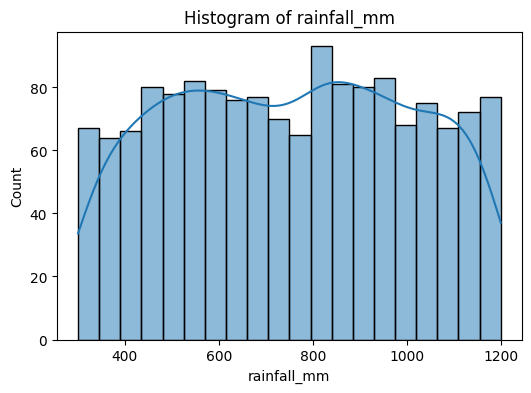

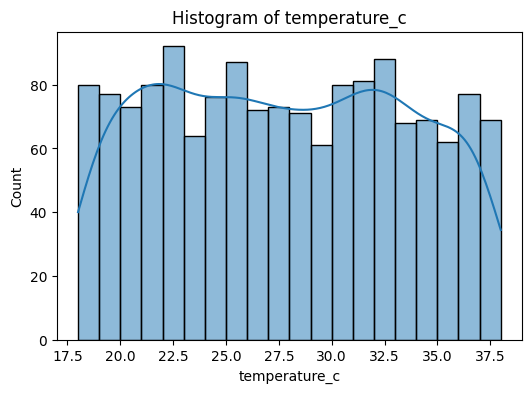

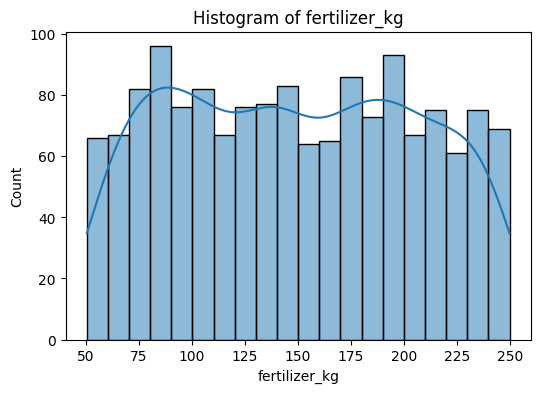

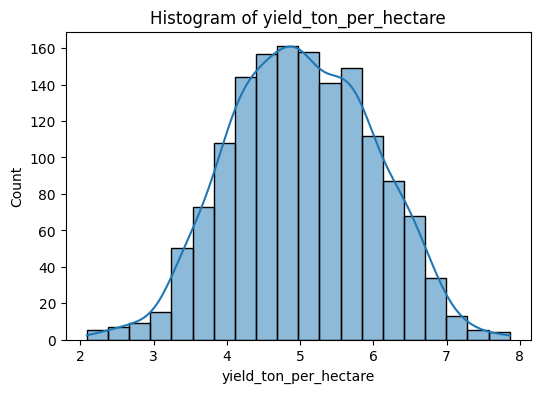

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
#Question-4
#Exploratory Data Analysis
features = ['rainfall_mm','temperature_c','fertilizer_kg','yield_ton_per_hectare']
for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Histogram of {col}")
    plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


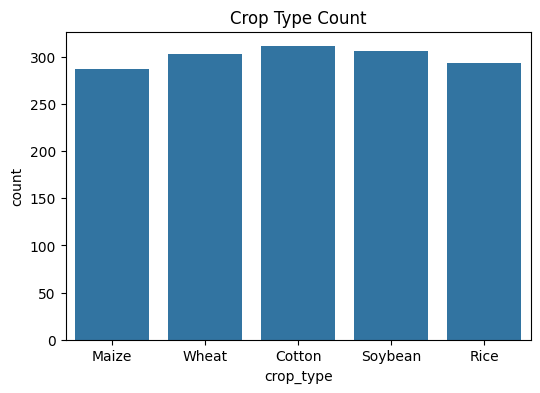

In [13]:
# Q5. Crop Type Analysis
print(df['crop_type'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='crop_type', data=df)
plt.title("Crop Type Count")
plt.show()


soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


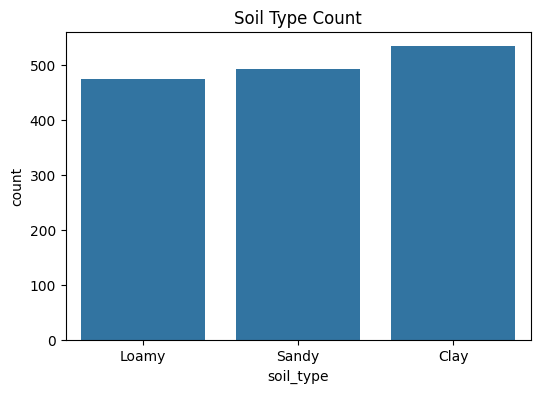

In [14]:
# Q6. Soil Type Analysis
print(df['soil_type'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='soil_type', data=df)
plt.title("Soil Type Count")
plt.show()


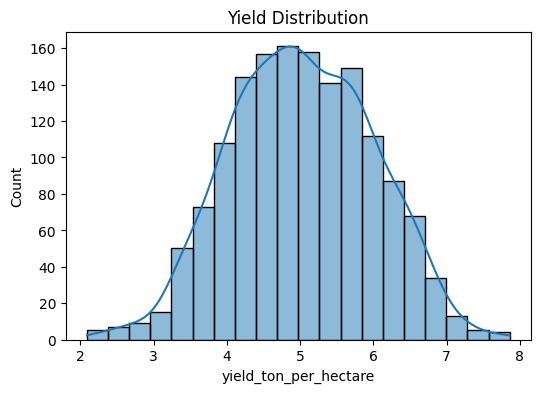

In [15]:
# Q7. Yield Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['yield_ton_per_hectare'], kde=True, bins=20)
plt.title("Yield Distribution")
plt.show()


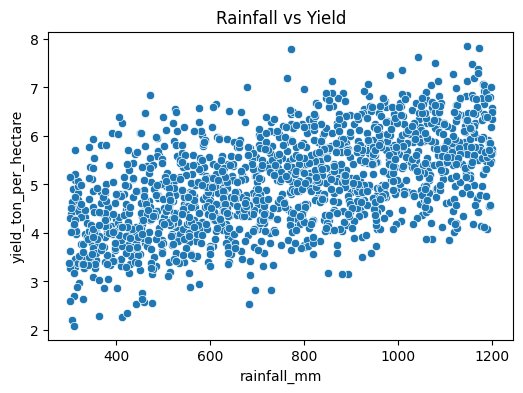

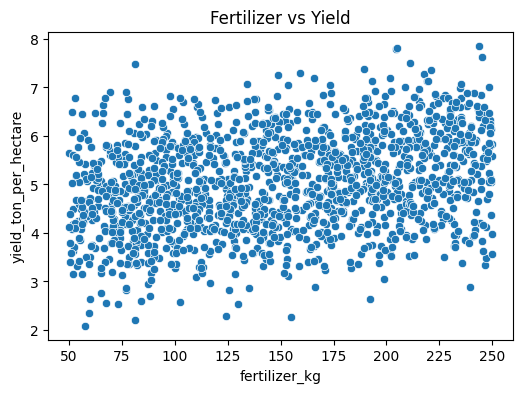

In [16]:
# Q8. Scatter Plot Analysis
plt.figure(figsize=(6,4))
sns.scatterplot(x='rainfall_mm', y='yield_ton_per_hectare', data=df)
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='fertilizer_kg', y='yield_ton_per_hectare', data=df)
plt.title("Fertilizer vs Yield")
plt.show()


                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

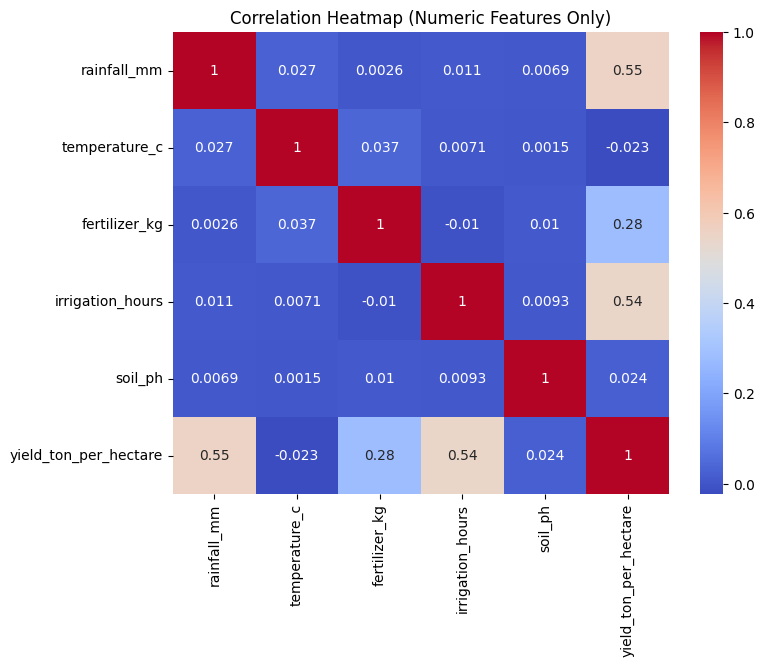

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
Name: yield_ton_per_hectare, dtype: float64


In [18]:
# Only select numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64','float64'])

corr = numeric_df.corr()
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

# Top 3 features most correlated with yield
print(corr['yield_ton_per_hectare'].sort_values(ascending=False).head(4))



In [19]:
# Q10. Group-Based Analysis
print("Average yield by crop type:")
print(df.groupby('crop_type')['yield_ton_per_hectare'].mean())

print("\nAverage yield by soil type:")
print(df.groupby('soil_type')['yield_ton_per_hectare'].mean())


Average yield by crop type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average yield by soil type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [20]:
#part-c
#data preparation
# Q11. Feature Encoding
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df_encoded.head())


Categorical Columns: Index(['crop_type', 'soil_type'], dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False  

In [21]:
# Q12. Feature Selection
X = df_encoded.drop('yield_ton_per_hectare', axis=1)
y = df_encoded['yield_ton_per_hectare']

print("Input Features (X):", X.shape)
print("Target Variable (y):", y.shape)


Input Features (X): (1500, 11)
Target Variable (y): (1500,)


In [22]:
#part-d
#machibne learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Q13. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (1200, 11)
X_test: (300, 11)
y_train: (1200,)
y_test: (300,)


In [23]:
# Q14. Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Feature with highest positive coefficient
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coef_df.sort_values(by='Coefficient', ascending=False).head(1))


Coefficients: [ 0.00203545 -0.00917496  0.00497799  0.19832728  0.00490119  0.23893088
  0.86399284  0.48171939  0.34847403  0.30297421 -0.49093272]
Intercept: 1.587132027736121
          Feature  Coefficient
6  crop_type_Rice     0.863993
